In [1]:
%load_ext autotime

import scarf
import scarf.plotting as splt

scarf.__version__

'1.0.0'

time: 2.28 s (started: 2026-07-17 01:22:16 +02:00)


In [2]:
scarf.fetch_dataset("tenx_5K_pbmc_rnaseq", save_path="scarf_datasets")

time: 19.7 s (started: 2026-07-17 01:22:18 +02:00)


In [3]:
reader = scarf.CrH5Reader("scarf_datasets/tenx_5K_pbmc_rnaseq/data.h5")

time: 15.8 ms (started: 2026-07-17 01:22:38 +02:00)


In [4]:
reader.nCells, reader.nFeatures

(5025, 33538)

time: 1.53 ms (started: 2026-07-17 01:22:38 +02:00)


In [5]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc="scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr",
    chunk_size=(2000, 1000),
)
writer.dump(batch_size=1000)

Writing countsT shape=(33538, 5025) chunks=(33538, 5025)



time: 37.7 s (started: 2026-07-17 01:22:38 +02:00)


In [6]:
ds = scarf.DataStore(
    "scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr", nthreads=4, min_features_per_cell=10
)

Minimum cell count (502) is lower than size factor multiplier (1000)



time: 6.43 s (started: 2026-07-17 01:23:14 +02:00)


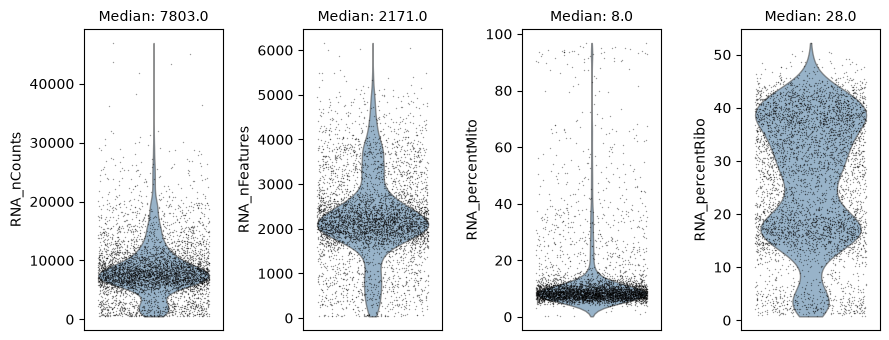

time: 1.17 s (started: 2026-07-17 01:23:19 +02:00)


In [7]:
ds.plot_cells_dists()

In [8]:
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
)

597 cells flagged for filtering out using attribute RNA_nCounts



461 cells flagged for filtering out using attribute RNA_nFeatures



612 cells flagged for filtering out using attribute RNA_percentMito



time: 77.5 ms (started: 2026-07-17 01:23:20 +02:00)


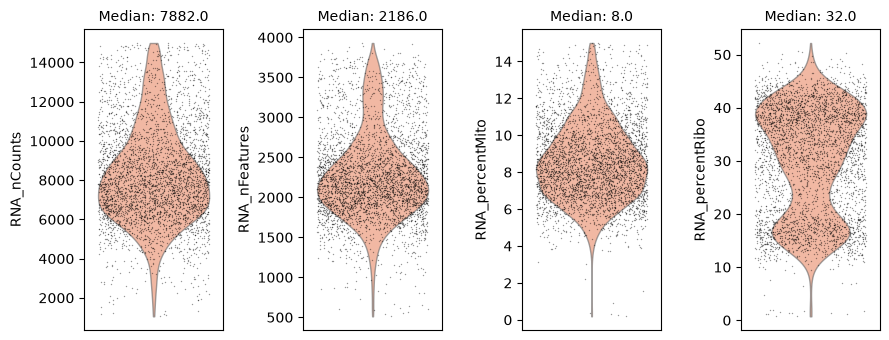

time: 591 ms (started: 2026-07-17 01:23:20 +02:00)


In [9]:
ds.plot_cells_dists(cell_key="I", color="coral")

In [10]:
ds.cells.head()

,I,ids,names,RNA_percentMito,RNA_percentRibo,RNA_nCounts,RNA_nFeatures
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,10.844353,16.783630,13537.0,3503.0
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,5.975687,20.034733,12668.0,3381.0
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,53.430353,2.494802,962.0,346.0
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,10.919143,28.783690,5788.0,1799.0
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,7.955407,35.750038,13186.0,2887.0


time: 119 ms (started: 2026-07-17 01:23:21 +02:00)


In [11]:
ds

DataStore has 3940 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_percentRibo', 
            'RNA_nFeatures', 'RNA_nCounts'
   RNA assay has 14283 (33538) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

time: 89.4 ms (started: 2026-07-17 01:23:21 +02:00)


In [12]:
ds.RNA.feats.head()

,I,ids,names,nCells,dropOuts
0,False,ENSG00000243485,MIR1302-2HG,0,5025
1,False,ENSG00000237613,FAM138A,0,5025
2,False,ENSG00000186092,OR4F5,0,5025
3,True,ENSG00000238009,AL627309.1,49,4976
4,False,ENSG00000239945,AL627309.3,3,5022


time: 77.8 ms (started: 2026-07-17 01:23:21 +02:00)


In [13]:
ds.RNA.sf

1000

time: 2.3 ms (started: 2026-07-17 01:23:21 +02:00)


Calculating summary statistics



(RNA) feature stats block 1/1: read 1.0s (r2) compute 0.3s rss 969 MiB



Calculating HVGs



498 genes marked as HVGs



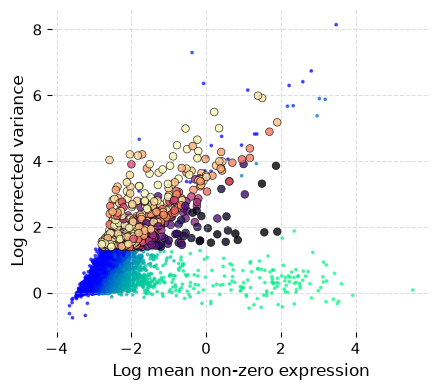

time: 2.85 s (started: 2026-07-17 01:23:21 +02:00)


In [14]:
ds.mark_hvgs(min_cells=20, top_n=500, min_mean=-3, max_mean=2, max_var=6)

In [15]:
ds.RNA.feats.head()

,I,ids,names,nCells,dropOuts,I__hvgs,stats_I_normed_tot,stats_I_normed_n,stats_I_avg,stats_I_nz_mean,stats_I_sigmas,stats_I_c_var__200__0.1
0,False,ENSG00000243485,MIR1302-2HG,0,5025,False,NaN,NaN,NaN,NaN,NaN,NaN
1,False,ENSG00000237613,FAM138A,0,5025,False,NaN,NaN,NaN,NaN,NaN,NaN
2,False,ENSG00000186092,OR4F5,0,5025,False,NaN,NaN,NaN,NaN,NaN,NaN
3,True,ENSG00000238009,AL627309.1,49,4976,False,4.593283,33.0,0.001166,0.13919,0.000196,1.5279
4,False,ENSG00000239945,AL627309.3,3,5022,False,NaN,NaN,NaN,NaN,NaN,NaN


time: 217 ms (started: 2026-07-17 01:23:24 +02:00)


In [16]:
ds.make_graph(feat_key="hvgs", k=11, dims=15, n_centroids=100)

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 1.1s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.0s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

ANN recall: 99.92%



make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 15.0s (7/7 steps, 15.0s in logged steps)



time: 15 s (started: 2026-07-17 01:23:24 +02:00)


In [17]:
ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True)

Training UMAP:   0%|                                                                                          …

time: 3.19 s (started: 2026-07-17 01:23:39 +02:00)


In [18]:
ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    use_density_map=True,
    label="dUMAP",
)

Training UMAP:   0%|                                                                                          …

time: 7.84 s (started: 2026-07-17 01:23:42 +02:00)


In [19]:
ds.cells.head()

,I,ids,names,RNA_percentMito,RNA_percentRibo,RNA_nFeatures,RNA_nCounts,RNA_UMAP2,RNA_dUMAP2,RNA_UMAP1,RNA_dUMAP1
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,10.844353,16.783630,3503.0,13537.0,24.742550,31.986763,5.887237,6.269168
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,5.975687,20.034733,3381.0,12668.0,27.014095,30.832750,-11.125002,-9.417094
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,53.430353,2.494802,346.0,962.0,NaN,NaN,NaN,NaN
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,10.919143,28.783690,1799.0,5788.0,14.179783,15.419672,0.032044,-1.512103
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,7.955407,35.750038,2887.0,13186.0,-8.660489,-7.711678,-24.615227,-13.947566


time: 216 ms (started: 2026-07-17 01:23:48 +02:00)


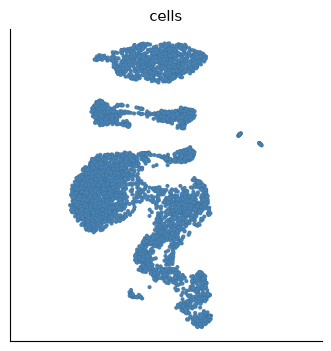

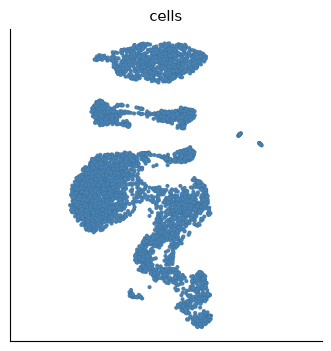

time: 330 ms (started: 2026-07-17 01:23:49 +02:00)


In [20]:
splt.embedding(ds, layout_key="RNA_UMAP", show=False).figure

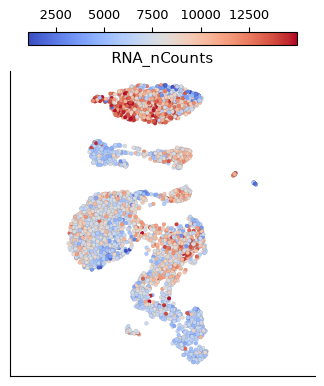

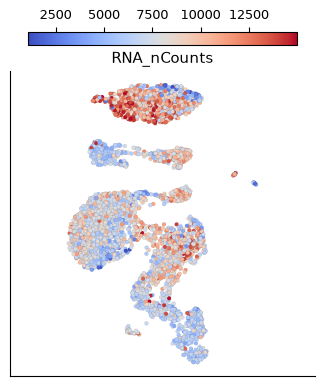

time: 553 ms (started: 2026-07-17 01:23:49 +02:00)


In [21]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_nCounts",
    color_scale=splt.ColorScale(cmap="coolwarm"),
    show=False,
).figure

In [22]:
ds.run_tsne(alpha=10, box_h=1, early_iter=250, max_iter=500, parallel=True)

parallel=True is not supported by the sgtsnepi Python backend; running single-threaded



Number of vertices: 3940


Embedding dimensions: 2


Rescaling parameter λ: 1


Early exag. multiplier α: 10


...

Iteration 450: error is 2.99385 (50 iterations in 0.162277 seconds)


Iteration 499: error is 2.99372 (50 iterations in 0.154903 seconds)


 --- Time spent in each module --- 



 Attractive forces: 0.25561 sec [22.5624%] |  Repulsive forces: 0.877293 sec [77.4376%]


time: 1.41 s (started: 2026-07-17 01:23:49 +02:00)


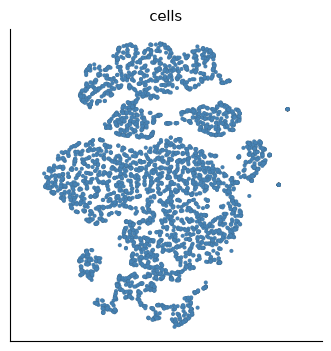

time: 291 ms (started: 2026-07-17 01:23:51 +02:00)


In [23]:
# If run_tsne is unavailable, the tSNE columns will not exist.
try:
    splt.embedding(ds, layout_key="RNA_tSNE", show=False).figure
except KeyError:
    print("'RNA_tSNE1' not found in MetaData")

In [24]:
# We start with Leiden clustering
ds.run_leiden_clustering(resolution=0.5)

time: 581 ms (started: 2026-07-17 01:23:51 +02:00)


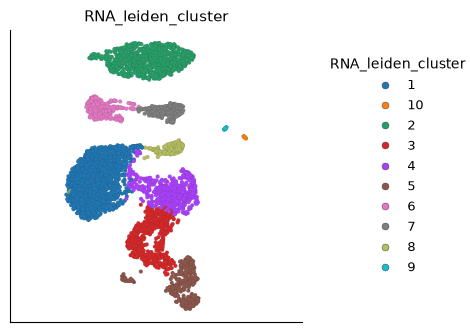

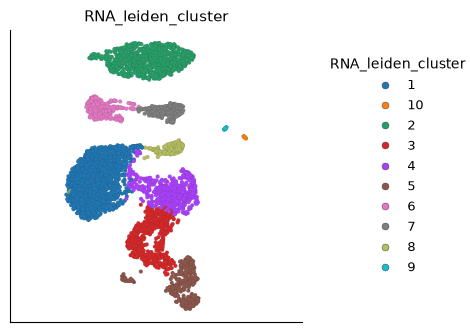

time: 686 ms (started: 2026-07-17 01:23:52 +02:00)


In [25]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_leiden_cluster",
    show=False,
).figure

In [26]:
ds.cells.head()

,I,ids,names,RNA_percentMito,RNA_tSNE2,RNA_tSNE1,RNA_percentRibo,RNA_nFeatures,RNA_nCounts,RNA_UMAP2,RNA_leiden_cluster,RNA_dUMAP1,RNA_dUMAP2,RNA_UMAP1
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,10.844353,19.278158,-9.354036,16.783630,3503.0,13537.0,24.742550,2,6.269168,31.986763,5.887237
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,5.975687,24.691764,9.886916,20.034733,3381.0,12668.0,27.014095,2,-9.417094,30.832750,-11.125002
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,53.430353,NaN,NaN,2.494802,346.0,962.0,NaN,-1,NaN,NaN,NaN
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,10.919143,13.630082,7.703735,28.783690,1799.0,5788.0,14.179783,7,-1.512103,15.419672,0.032044
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,7.955407,5.660443,-12.027192,35.750038,2887.0,13186.0,-8.660489,1,-13.947566,-7.711678,-24.615227


time: 307 ms (started: 2026-07-17 01:23:52 +02:00)


In [27]:
leiden_clusters = ds.cells.to_pandas_dataframe(columns=["RNA_leiden_cluster"], key="I")
leiden_clusters.head()

,RNA_leiden_cluster
0,2
1,2
3,7
4,1
6,5


time: 85.6 ms (started: 2026-07-17 01:23:53 +02:00)


In [28]:
ds.run_clustering(n_clusters=leiden_clusters.nunique()[0])

/tmp/ipykernel_1199302/1807300542.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ds.run_clustering(n_clusters=leiden_clusters.nunique()[0])


time: 440 ms (started: 2026-07-17 01:23:53 +02:00)


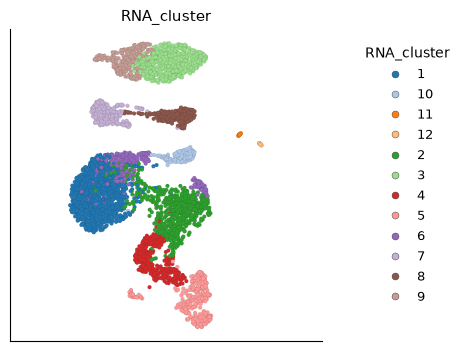

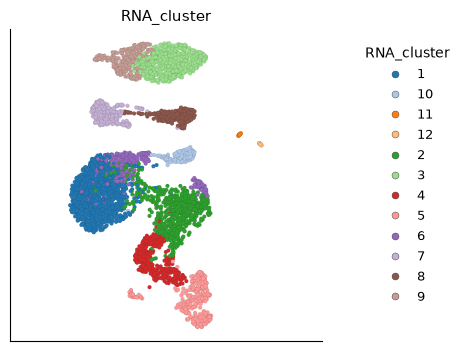

time: 647 ms (started: 2026-07-17 01:23:53 +02:00)


In [29]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_cluster",
    show=False,
).figure

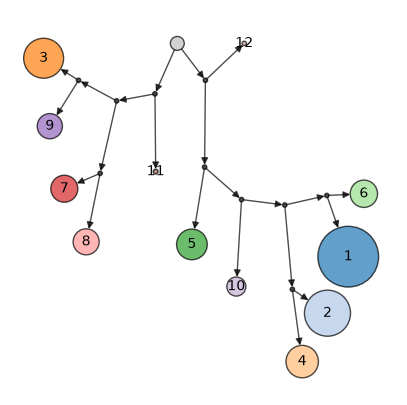

time: 443 ms (started: 2026-07-17 01:23:54 +02:00)


In [30]:
splt.cluster_tree(ds, cluster_key="RNA_cluster", width=1)

In [31]:
ds.run_marker_search(group_key="RNA_cluster", gene_batch_size=100)

Saved marker results to RNA/markers/I__RNA_cluster in 1.0s (12 clusters, layout=compact_v2)



time: 1min 57s (started: 2026-07-17 01:23:54 +02:00)


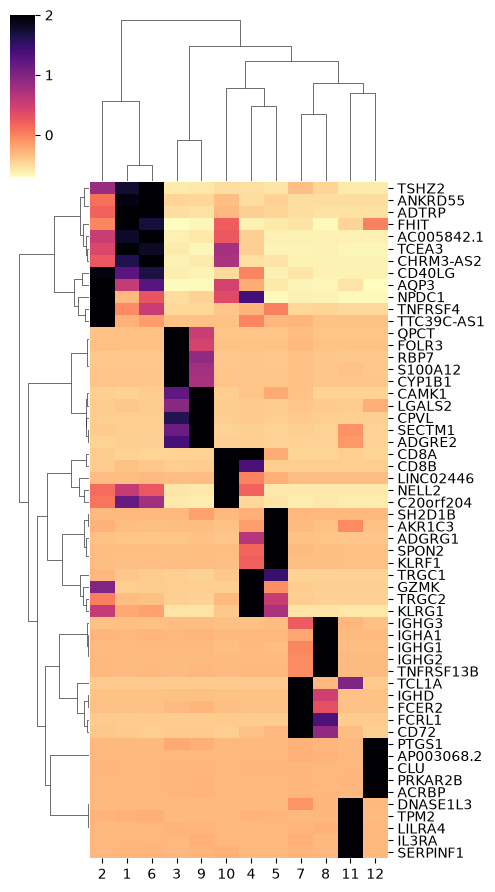

time: 3.44 s (started: 2026-07-17 01:25:47 +02:00)


In [32]:
splt.marker_heatmap(ds, group_key="RNA_cluster", topn=5, figsize=(5, 9))

In [33]:
df = ds.get_markers(
    group_key="RNA_cluster", group_id="1", min_score=-1, min_frac_exp=-1
)
df

,group_id,feature_name,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,feature_index
0,1,ADTRP,0.39357,0.04230,0.00660,0.23891,0.04172,6.40627,7.916987e-79,4325
1,1,FHIT,0.34500,0.14826,0.02411,0.61895,0.14213,6.14990,2.099062e-211,2768
2,1,TSHZ2,0.33229,0.06775,0.01768,0.32157,0.07598,3.83252,4.108312e-83,12544
3,1,TCEA3,0.32824,0.03142,0.00677,0.21169,0.04851,4.64027,1.191801e-55,225
4,1,ANKRD55,0.32088,0.02067,0.00345,0.13810,0.02544,5.98548,1.976907e-42,3795
...,...,...,...,...,...,...,...,...,...,...
14278,1,LYN,0.00118,0.00220,0.11326,0.01815,0.39722,0.01944,1.425056e-110,6305
14279,1,ZEB2,0.00113,0.00255,0.19569,0.01915,0.49050,0.01304,2.901976e-149,2035
14280,1,MARCH1,0.00098,0.00070,0.09711,0.00605,0.34600,0.00716,8.621413e-97,3629
14281,1,MEF2C,0.00091,0.00065,0.09722,0.00504,0.32972,0.00667,2.741006e-91,3909


time: 274 ms (started: 2026-07-17 01:25:48 +02:00)


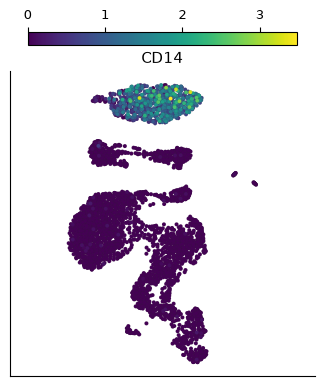

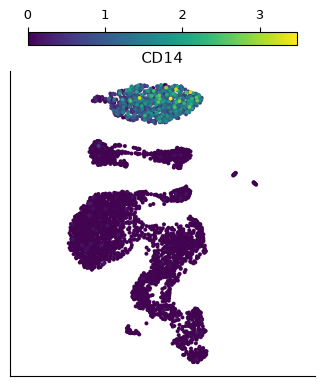

time: 13.5 s (started: 2026-07-17 01:25:49 +02:00)


In [34]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="CD14",
    sort_values=True,
    show=False,
).figure